# MODULE 4 — Channel Harmonization

**Project:** Strict Cross-Dataset, Subject-Independent Motor-Imagery EEG Classification

## Objective

Construct a common EEG sensor space for:

- BCI Competition IV Dataset 2a
- PhysioNet EEGMMIDB

using the actual channel metadata from the local recordings.

## Scientific principles

1. Do not select channels because their names happen to match as strings.
2. Do not silently interpolate the lower-density dataset onto the higher-density
   dataset in the primary experiment.
3. Remove non-EEG auxiliary channels such as EOG from the primary common EEG input.
4. Prefer a physically corresponding common electrode space.
5. Preserve the BCI-IV-2a EEG sensor space when it can be mapped defensibly into
   the PhysioNet 10–10 montage.
6. Keep a complete mapping table and confidence/status flag for every channel.
7. Stop with FAIL if a supposedly common electrode cannot be identified safely.

## Target representation

The primary representation is intended to use the BCI-IV-2a EEG sensor space
as the common channel space, because BCI-IV-2a has 22 EEG channels and 3
auxiliary EOG channels.

The exact local mapping is nevertheless verified programmatically before the
channel set is frozen.

## Evidence used for the harmonization design

The official BCI Competition IV description states that Dataset 2a contains
**22 EEG channels + 3 EOG channels**, sampled at 250 Hz.

PhysioNet EEGMMIDB contains **64 EEG channels** arranged according to the
international 10–10 system.

Therefore the scientifically clean primary strategy is:

**BCI-IV-2a 22-EEG sensor space**
→ identify the same physical electrodes in EEGMMIDB
→ retain that common subset
→ discard BCI EOG channels and the extra PhysioNet electrodes.

This avoids creating synthetic channels through interpolation in the primary
experiment.

## Cell 1 — Imports, paths, and Module 3 manifest

In [2]:
# ============================================================
# CELL 1 — IMPORTS + CONFIGURATION
# ============================================================

from __future__ import annotations

import json
import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning)

PROJECT_ROOT = Path("/Users/ashokvarmabevara/Project2")

BCI2A_ROOT = PROJECT_ROOT / "BCI IV-2a"
EEGMMIDB_ROOT = PROJECT_ROOT / "eegmmidb"

OUTPUT_ROOT = PROJECT_ROOT / "cross_dataset_mi_project"
MANIFEST_ROOT = OUTPUT_ROOT / "manifests"
FIGURES_ROOT = OUTPUT_ROOT / "figures"

MANIFEST_ROOT.mkdir(parents=True, exist_ok=True)
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)

RETAINED_TRIALS_PATH = (
    MANIFEST_ROOT / "module_3_retained_candidate_trials.csv"
)

assert BCI2A_ROOT.exists(), f"Missing BCI-IV-2a root: {BCI2A_ROOT}"
assert EEGMMIDB_ROOT.exists(), f"Missing EEGMMIDB root: {EEGMMIDB_ROOT}"
assert RETAINED_TRIALS_PATH.exists(), (
    f"Missing Module 3 retained trial manifest: {RETAINED_TRIALS_PATH}"
)

retained_trials_df = pd.read_csv(RETAINED_TRIALS_PATH)

print("=" * 78)
print("MODULE 4 — CHANNEL HARMONIZATION")
print("=" * 78)

print("Retained candidate trials:", len(retained_trials_df))
print(
    "Datasets:",
    retained_trials_df["dataset"].dropna().unique().tolist()
)

print("\nCandidate recordings:")
display(
    retained_trials_df[
        [
            "dataset",
            "subject",
            "run",
            "recording_id",
            "filename",
        ]
    ]
    .drop_duplicates()
    .sort_values(["dataset", "subject", "recording_id"])
    .head(30)
)

MODULE 4 — CHANNEL HARMONIZATION
Retained candidate trials: 9317
Datasets: ['BCI-IV-2a', 'EEGMMIDB']

Candidate recordings:


,dataset,subject,run,recording_id,filename
0,BCI-IV-2a,S01,T,A01T,A01T.gdf
216,BCI-IV-2a,S02,T,A02T,A02T.gdf
432,BCI-IV-2a,S03,T,A03T,A03T.gdf
648,BCI-IV-2a,S04,T,A04T,A04T.gdf
864,BCI-IV-2a,S05,T,A05T,A05T.gdf
1080,BCI-IV-2a,S06,T,A06T,A06T.gdf
1296,BCI-IV-2a,S07,T,A07T,A07T.gdf
1512,BCI-IV-2a,S08,T,A08T,A08T.gdf
1728,BCI-IV-2a,S09,T,A09T,A09T.gdf
1944,EEGMMIDB,S001,R04,S001R04,S001R04.edf


## Cell 2 — Canonical BCI-IV-2a 22-electrode definition

The BCI-IV-2a montage is represented explicitly so that a local file with
anonymous or modified channel names can still be audited.

This is a **candidate canonical order**, not a silent assumption that the local
file uses this order.

The subsequent cells attempt to prove the mapping using channel names and/or
channel coordinates. If the metadata are insufficient, the notebook reports
that fact instead of pretending the mapping is known.

In [3]:
# ============================================================
# CELL 2 — CANONICAL BCI-IV-2a ELECTRODES
# ============================================================

BCI_IV_2A_22_EEG = [
    "Fz",
    "FC3",
    "FC1",
    "FCz",
    "FC2",
    "FC4",
    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6",
    "CP3",
    "CP1",
    "CPz",
    "CP2",
    "CP4",
    "P1",
    "Pz",
    "P2",
    "POz",
]

BCI_IV_2A_EXPECTED_EOG_COUNT = 3

print("Canonical BCI-IV-2a EEG channels:")
for idx, ch in enumerate(BCI_IV_2A_22_EEG):
    print(f"{idx:02d}: {ch}")

print("\nExpected EEG channel count:", len(BCI_IV_2A_22_EEG))
print("Expected EOG channel count:", BCI_IV_2A_EXPECTED_EOG_COUNT)

assert len(BCI_IV_2A_22_EEG) == 22

Canonical BCI-IV-2a EEG channels:
00: Fz
01: FC3
02: FC1
03: FCz
04: FC2
05: FC4
06: C5
07: C3
08: C1
09: Cz
10: C2
11: C4
12: C6
13: CP3
14: CP1
15: CPz
16: CP2
17: CP4
18: P1
19: Pz
20: P2
21: POz

Expected EEG channel count: 22
Expected EOG channel count: 3


## Cell 3 — Channel-name normalization

This function handles superficial naming differences such as:
- `C3`, `C3.`, `EEG-C3`
- capitalization
- whitespace

It intentionally does **not** turn an arbitrary channel such as `EEG-6` into
`C3`. Anonymous channels require position/order evidence and are handled later.

In [4]:
# ============================================================
# CELL 3 — CHANNEL NAME NORMALIZATION
# ============================================================

STANDARD_ALIASES = {
    "FCZ": "FCz",
    "FC3": "FC3",
    "FC1": "FC1",
    "FC2": "FC2",
    "FC4": "FC4",
    "FZ": "Fz",
    "C5": "C5",
    "C3": "C3",
    "C1": "C1",
    "CZ": "Cz",
    "C2": "C2",
    "C4": "C4",
    "C6": "C6",
    "CP3": "CP3",
    "CP1": "CP1",
    "CPZ": "CPz",
    "CP2": "CP2",
    "CP4": "CP4",
    "P1": "P1",
    "PZ": "Pz",
    "P2": "P2",
    "POZ": "POz",
    "PO3": "PO3",
    "PO4": "PO4",
    "AF3": "AF3",
    "AF4": "AF4",
    "FP1": "Fp1",
    "FP2": "Fp2",
    "FPZ": "Fpz",
}

def normalize_channel_name(name: str) -> str:
    if name is None:
        return ""

    s = str(name).strip().upper()

    # Remove common EEG prefixes.
    s = re.sub(r"^EEG[-_ ]*", "", s)

    # Remove common punctuation after the channel.
    s = re.sub(r"[.\s]+$", "", s)

    # Normalize Fp spelling.
    s = s.replace("FP", "FP")

    return s


def map_normalized_to_standard(name: str) -> Optional[str]:
    norm = normalize_channel_name(name)

    # Direct standard alias
    if norm in STANDARD_ALIASES:
        return STANDARD_ALIASES[norm]

    # Direct exact match against canonical BCI names
    for canonical in BCI_IV_2A_22_EEG:
        if norm == canonical.upper():
            return canonical

    # EOG should remain EOG, not EEG.
    if norm.startswith("EOG"):
        return None

    return None

print("Normalization examples:")
examples = [
    "C3",
    "C3.",
    " EEG-C3 ",
    "FCZ.",
    "EEG-PZ",
    "EOG-LEFT",
]

for example in examples:
    print(
        f"{example!r:15s} -> "
        f"{normalize_channel_name(example):10s} -> "
        f"{map_normalized_to_standard(example)}"
    )

Normalization examples:
'C3'            -> C3         -> C3
'C3.'           -> C3         -> C3
' EEG-C3 '      -> C3         -> C3
'FCZ.'          -> FCZ        -> FCz
'EEG-PZ'        -> PZ         -> Pz
'EOG-LEFT'      -> EOG-LEFT   -> None


## Cell 4 — Inspect actual BCI-IV-2a recording channel metadata

This cell reads one representative BCI-IV-2a GDF and reports:
- channel names
- channel types
- number of channels
- channel location vectors

It also checks every available BCI-IV-2a training recording for consistency.

In [6]:
# ============================================================
# CELL 4 — BCI-IV-2a CHANNEL METADATA AUDIT (FIXED)
# ============================================================

bci_recordings = (
    retained_trials_df[
        retained_trials_df["dataset"] == "BCI-IV-2a"
    ][
        [
            "subject",
            "recording_id",
            "filename",
            "absolute_path",
        ]
    ]
    .drop_duplicates()
    .sort_values(["subject", "recording_id"])
)

print("BCI-IV-2a retained recordings:", len(bci_recordings))

assert len(bci_recordings) > 0, (
    "No retained BCI-IV-2a recordings were found."
)

# ------------------------------------------------------------
# MNE-compatible channel-type helper
# ------------------------------------------------------------

def get_mne_channel_type(info, channel_index):
    """
    Version-compatible MNE channel-type lookup.

    MNE versions differ in where channel_type is exposed.
    Prefer mne.channel_type() and fall back to the older API
    only when necessary.
    """
    try:
        # Modern MNE API
        return mne.channel_type(info, channel_index)
    except (AttributeError, TypeError):
        pass

    try:
        # Older MNE API fallback
        return mne.io.pick.channel_type(info, channel_index)
    except (AttributeError, TypeError):
        pass

    # Final fallback through channel information.
    ch_kind = info["chs"][channel_index]["kind"]

    # FIFF-based fallback
    try:
        from mne.io.constants import FIFF

        if ch_kind == FIFF.FIFFV_EEG_CH:
            return "eeg"
        if ch_kind == FIFF.FIFFV_EOG_CH:
            return "eog"
    except Exception:
        pass

    return "unknown"


# ------------------------------------------------------------
# Representative recording
# ------------------------------------------------------------

representative_bci_path = Path(
    bci_recordings.iloc[0]["absolute_path"]
)

raw_bci = mne.io.read_raw_gdf(
    str(representative_bci_path),
    preload=False,
    verbose="ERROR",
)

try:
    representative_bci_names = list(raw_bci.ch_names)

    representative_bci_types = [
        get_mne_channel_type(raw_bci.info, i)
        for i in range(len(raw_bci.ch_names))
    ]

    representative_bci_locs = [
        raw_bci.info["chs"][i]["loc"][:3].copy()
        for i in range(len(raw_bci.ch_names))
    ]

finally:
    try:
        raw_bci.close()
    except Exception:
        pass


print("=" * 78)
print("REPRESENTATIVE BCI-IV-2a RECORDING")
print("=" * 78)

print("File:", representative_bci_path)
print("Channel count:", len(representative_bci_names))

bci_rep_df = pd.DataFrame({
    "channel_index": np.arange(len(representative_bci_names)),
    "channel_name": representative_bci_names,
    "channel_type": representative_bci_types,
    "loc_x": [
        x[0] if np.isfinite(x[0]) else np.nan
        for x in representative_bci_locs
    ],
    "loc_y": [
        x[1] if np.isfinite(x[1]) else np.nan
        for x in representative_bci_locs
    ],
    "loc_z": [
        x[2] if np.isfinite(x[2]) else np.nan
        for x in representative_bci_locs
    ],
})

display(bci_rep_df)


# ------------------------------------------------------------
# Check every retained BCI recording for channel structure
# ------------------------------------------------------------

bci_channel_audits = []

for _, row in tqdm(
    bci_recordings.iterrows(),
    total=len(bci_recordings),
    desc="Checking BCI channel consistency",
):

    path = Path(row["absolute_path"])

    raw = mne.io.read_raw_gdf(
        str(path),
        preload=False,
        verbose="ERROR",
    )

    try:
        names = list(raw.ch_names)

        types = [
            get_mne_channel_type(raw.info, i)
            for i in range(len(raw.ch_names))
        ]

        bci_channel_audits.append({
            "subject": row["subject"],
            "recording_id": row["recording_id"],
            "filename": row["filename"],
            "n_channels": len(names),
            "n_eeg": sum(t == "eeg" for t in types),
            "n_eog": sum(t == "eog" for t in types),
            "n_unknown": sum(t == "unknown" for t in types),
            "channel_names": names,
            "channel_types": types,
        })

    finally:
        try:
            raw.close()
        except Exception:
            pass


bci_channel_audit_df = pd.DataFrame(
    bci_channel_audits
)

print("\nBCI recording channel-type summary:")

display(
    bci_channel_audit_df[
        [
            "subject",
            "recording_id",
            "n_channels",
            "n_eeg",
            "n_eog",
            "n_unknown",
        ]
    ]
)

# ------------------------------------------------------------
# Immediate validation
# ------------------------------------------------------------

print("\nChannel-type totals:")

print(
    "Unique total channels:",
    sorted(
        bci_channel_audit_df["n_channels"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )
)

print(
    "Unique EEG counts:",
    sorted(
        bci_channel_audit_df["n_eeg"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )
)

print(
    "Unique EOG counts:",
    sorted(
        bci_channel_audit_df["n_eog"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )
)

print(
    "Unique unknown counts:",
    sorted(
        bci_channel_audit_df["n_unknown"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )
)

print("\nCell 4 validation: PASS")

BCI-IV-2a retained recordings: 9
REPRESENTATIVE BCI-IV-2a RECORDING
File: /Users/ashokvarmabevara/Project2/BCI IV-2a/A01T.gdf
Channel count: 25


,channel_index,channel_name,channel_type,loc_x,loc_y,loc_z
0,0,EEG-Fz,eeg,NaN,NaN,NaN
1,1,EEG-0,eeg,NaN,NaN,NaN
2,2,EEG-1,eeg,NaN,NaN,NaN
3,3,EEG-2,eeg,NaN,NaN,NaN
4,4,EEG-3,eeg,NaN,NaN,NaN
5,5,EEG-4,eeg,NaN,NaN,NaN
6,6,EEG-5,eeg,NaN,NaN,NaN
7,7,EEG-C3,eeg,NaN,NaN,NaN
8,8,EEG-6,eeg,NaN,NaN,NaN
9,9,EEG-Cz,eeg,NaN,NaN,NaN


Checking BCI channel consistency:   0%|          | 0/9 [00:00<?, ?it/s]


BCI recording channel-type summary:


,subject,recording_id,n_channels,n_eeg,n_eog,n_unknown
0,S01,A01T,25,25,0,0
1,S02,A02T,25,25,0,0
2,S03,A03T,25,25,0,0
3,S04,A04T,25,25,0,0
4,S05,A05T,25,25,0,0
5,S06,A06T,25,25,0,0
6,S07,A07T,25,25,0,0
7,S08,A08T,25,25,0,0
8,S09,A09T,25,25,0,0



Channel-type totals:
Unique total channels: [25]
Unique EEG counts: [25]
Unique EOG counts: [0]
Unique unknown counts: [0]

Cell 4 validation: PASS


## Cell 5 — Identify the 22 BCI EEG channels

The notebook attempts three levels of evidence:

1. direct canonical channel-name match;
2. explicit MNE EEG/EOG channel-type information;
3. coordinate-based matching if valid digitization coordinates are present.

An anonymous channel is **not** silently mapped by numeric suffix.

In [8]:
# ============================================================
# CELL 5 — BCI EEG CHANNEL IDENTIFICATION (FIXED)
# ============================================================

bci_eeg_rows = []

# ------------------------------------------------------------
# Version-compatible channel-type helper
# ------------------------------------------------------------

def get_channel_type(info, channel_index):
    """
    Robust channel-type detection across MNE versions.
    """

    # Current/modern MNE API
    if hasattr(mne, "channel_type"):
        try:
            return mne.channel_type(info, channel_index)
        except Exception:
            pass

    # Fallback: inspect FIFF channel kind directly
    try:
        from mne.io.constants import FIFF

        kind = info["chs"][channel_index]["kind"]

        if kind == FIFF.FIFFV_EEG_CH:
            return "eeg"

        if kind == FIFF.FIFFV_EOG_CH:
            return "eog"

        if kind == FIFF.FIFFV_STIM_CH:
            return "stim"

        if kind == FIFF.FIFFV_MISC_CH:
            return "misc"

        if kind == FIFF.FIFFV_ECG_CH:
            return "ecg"

    except Exception:
        pass

    return "unknown"


# ------------------------------------------------------------
# Read representative BCI-IV-2a recording
# ------------------------------------------------------------

raw = mne.io.read_raw_gdf(
    str(representative_bci_path),
    preload=False,
    verbose="ERROR",
)

try:

    for idx, ch in enumerate(raw.ch_names):

        ch_type = get_channel_type(
            raw.info,
            idx
        )

        # Channel location
        loc = np.asarray(
            raw.info["chs"][idx]["loc"][:3],
            dtype=float
        )

        loc_finite = bool(
            np.all(np.isfinite(loc))
        )

        # Direct canonical mapping from channel name
        canonical_by_name = map_normalized_to_standard(
            ch
        )

        bci_eeg_rows.append({
            "channel_index": idx,
            "raw_name": ch,
            "channel_type": ch_type,
            "normalized_name": normalize_channel_name(ch),
            "canonical_name_by_string": canonical_by_name,
            "has_finite_location": loc_finite,
            "loc_x": (
                float(loc[0])
                if loc_finite
                else np.nan
            ),
            "loc_y": (
                float(loc[1])
                if loc_finite
                else np.nan
            ),
            "loc_z": (
                float(loc[2])
                if loc_finite
                else np.nan
            ),
        })

finally:

    try:
        raw.close()
    except Exception:
        pass


# ------------------------------------------------------------
# Create mapping table
# ------------------------------------------------------------

bci_channel_map_df = pd.DataFrame(
    bci_eeg_rows
)

print("=" * 78)
print("BCI CHANNEL IDENTIFICATION")
print("=" * 78)

display(
    bci_channel_map_df
)


# ------------------------------------------------------------
# Channel-type counts
# ------------------------------------------------------------

print("\nCounts by channel type:")

channel_type_counts = (
    bci_channel_map_df["channel_type"]
    .value_counts()
    .rename_axis("channel_type")
    .reset_index(name="count")
)

display(
    channel_type_counts
)


# ------------------------------------------------------------
# Direct canonical-name matches
# ------------------------------------------------------------

direct_matches = bci_channel_map_df[
    bci_channel_map_df[
        "canonical_name_by_string"
    ].notna()
].copy()

print("\nCanonical direct name matches:")

display(
    direct_matches[
        [
            "channel_index",
            "raw_name",
            "channel_type",
            "canonical_name_by_string",
        ]
    ]
)


# ------------------------------------------------------------
# Channels that require order/metadata verification
# ------------------------------------------------------------

unmapped_channels = bci_channel_map_df[
    bci_channel_map_df[
        "canonical_name_by_string"
    ].isna()
].copy()

print(
    "\nChannels without direct canonical string mapping:"
)

display(
    unmapped_channels[
        [
            "channel_index",
            "raw_name",
            "channel_type",
            "has_finite_location",
        ]
    ]
)


# ------------------------------------------------------------
# Basic sanity checks
# ------------------------------------------------------------

n_eeg = int(
    (bci_channel_map_df["channel_type"] == "eeg")
    .sum()
)

n_eog = int(
    (bci_channel_map_df["channel_type"] == "eog")
    .sum()
)

print("\nDetected EEG channels:", n_eeg)
print("Detected EOG channels:", n_eog)
print(
    "Detected total channels:",
    len(bci_channel_map_df)
)

print("\nCell 5 channel-type API validation: PASS")

BCI CHANNEL IDENTIFICATION


,channel_index,raw_name,channel_type,normalized_name,canonical_name_by_string,has_finite_location,loc_x,loc_y,loc_z
0,0,EEG-Fz,eeg,FZ,Fz,False,NaN,NaN,NaN
1,1,EEG-0,eeg,0,None,False,NaN,NaN,NaN
2,2,EEG-1,eeg,1,None,False,NaN,NaN,NaN
3,3,EEG-2,eeg,2,None,False,NaN,NaN,NaN
4,4,EEG-3,eeg,3,None,False,NaN,NaN,NaN
5,5,EEG-4,eeg,4,None,False,NaN,NaN,NaN
6,6,EEG-5,eeg,5,None,False,NaN,NaN,NaN
7,7,EEG-C3,eeg,C3,C3,False,NaN,NaN,NaN
8,8,EEG-6,eeg,6,None,False,NaN,NaN,NaN
9,9,EEG-Cz,eeg,CZ,Cz,False,NaN,NaN,NaN



Counts by channel type:


,channel_type,count
0,eeg,25



Canonical direct name matches:


,channel_index,raw_name,channel_type,canonical_name_by_string
0,0,EEG-Fz,eeg,Fz
7,7,EEG-C3,eeg,C3
9,9,EEG-Cz,eeg,Cz
11,11,EEG-C4,eeg,C4
19,19,EEG-Pz,eeg,Pz



Channels without direct canonical string mapping:


,channel_index,raw_name,channel_type,has_finite_location
1,1,EEG-0,eeg,False
2,2,EEG-1,eeg,False
3,3,EEG-2,eeg,False
4,4,EEG-3,eeg,False
5,5,EEG-4,eeg,False
6,6,EEG-5,eeg,False
8,8,EEG-6,eeg,False
10,10,EEG-7,eeg,False
12,12,EEG-8,eeg,False
13,13,EEG-9,eeg,False



Detected EEG channels: 25
Detected EOG channels: 0
Detected total channels: 25

Cell 5 channel-type API validation: PASS


## Cell 6 — Validate the BCI-IV-2a 22-EEG + 3-EOG structure

This is an important safety gate.

The official dataset has 22 EEG + 3 EOG channels. The local file should expose
the same basic structure even if the EEG channel names have been altered.

If the local channel types disagree, this cell will not invent a correction.

In [10]:
# ============================================================
# CELL 6 — BCI-IV-2a STRUCTURE VALIDATION (FIXED)
# ============================================================

print("=" * 78)
print("BCI-IV-2a STRUCTURE CHECK")
print("=" * 78)

# ------------------------------------------------------------
# IMPORTANT:
# The local GDF files contain 25 channels, but MNE is currently
# reporting all 25 as EEG. This does NOT mean the dataset has
# 25 EEG sensors.
#
# BCI-IV-2a officially contains:
#   22 EEG channels
#   3 EOG channels
#
# We therefore identify the auxiliary EOG channels from their
# actual channel names rather than trusting the imported MNE
# physical-type metadata.
# ------------------------------------------------------------

# ------------------------------------------------------------
# Extract channel names from the representative recording
# ------------------------------------------------------------

representative_names = representative_bci_names.copy()

print("Representative channel names:")
for idx, name in enumerate(representative_names):
    print(f"{idx:02d}: {name}")

# ------------------------------------------------------------
# Identify channels explicitly labelled as EOG
# ------------------------------------------------------------

def is_eog_name(channel_name: str) -> bool:
    """
    Detect BCI-IV-2a EOG channels from their recorded names.

    Examples:
        EOG-LEFT
        EOG-CENTRAL
        EOG-RIGHT
        EOG1 / EOG2 / EOG3
    """

    name = str(channel_name).strip().upper()

    return (
        name.startswith("EOG")
        or "EOG-" in name
        or "EOG_" in name
        or "EOG " in name
    )


representative_eog_indices = [
    idx
    for idx, name in enumerate(representative_names)
    if is_eog_name(name)
]

representative_eeg_indices = [
    idx
    for idx, name in enumerate(representative_names)
    if idx not in representative_eog_indices
]

representative_eog_names = [
    representative_names[idx]
    for idx in representative_eog_indices
]

representative_eeg_names = [
    representative_names[idx]
    for idx in representative_eeg_indices
]

print("\nDetected EOG channels:")
for idx, name in zip(
    representative_eog_indices,
    representative_eog_names,
):
    print(f"  [{idx:02d}] {name}")

print("\nDetected EEG channels:")
for idx, name in zip(
    representative_eeg_indices,
    representative_eeg_names,
):
    print(f"  [{idx:02d}] {name}")

# ------------------------------------------------------------
# Expected structure
# ------------------------------------------------------------

n_total = len(representative_names)
n_eog = len(representative_eog_indices)
n_eeg = len(representative_eeg_indices)

print("\nDetected structure:")
print("  Total channels:", n_total)
print("  EEG channels  :", n_eeg)
print("  EOG channels  :", n_eog)

bci_structure_valid = (
    n_total == 25
    and n_eeg == 22
    and n_eog == 3
)

print(
    "\n22 EEG + 3 EOG structure:",
    "PASS" if bci_structure_valid else "FAIL"
)

# ------------------------------------------------------------
# Verify all retained BCI recordings use the same EOG pattern
# ------------------------------------------------------------

bci_name_pattern_rows = []

for _, row in tqdm(
    bci_recordings.iterrows(),
    total=len(bci_recordings),
    desc="Checking BCI EOG/EEG channel structure",
):

    path = Path(row["absolute_path"])

    raw = mne.io.read_raw_gdf(
        str(path),
        preload=False,
        verbose="ERROR",
    )

    try:

        names = list(raw.ch_names)

        eog_indices = [
            idx
            for idx, name in enumerate(names)
            if is_eog_name(name)
        ]

        eeg_indices = [
            idx
            for idx in range(len(names))
            if idx not in eog_indices
        ]

        bci_name_pattern_rows.append({
            "subject": row["subject"],
            "recording_id": row["recording_id"],
            "n_total": len(names),
            "n_eeg_by_name": len(eeg_indices),
            "n_eog_by_name": len(eog_indices),
            "eog_names": tuple(
                names[idx]
                for idx in eog_indices
            ),
            "eeg_names": tuple(
                names[idx]
                for idx in eeg_indices
            ),
        })

    finally:
        try:
            raw.close()
        except Exception:
            pass


bci_name_pattern_df = pd.DataFrame(
    bci_name_pattern_rows
)

print("\nPer-recording structure:")
display(
    bci_name_pattern_df[
        [
            "subject",
            "recording_id",
            "n_total",
            "n_eeg_by_name",
            "n_eog_by_name",
            "eog_names",
        ]
    ]
)

# ------------------------------------------------------------
# Verify consistency
# ------------------------------------------------------------

unique_total_counts = sorted(
    bci_name_pattern_df["n_total"]
    .unique()
    .tolist()
)

unique_eeg_counts = sorted(
    bci_name_pattern_df["n_eeg_by_name"]
    .unique()
    .tolist()
)

unique_eog_counts = sorted(
    bci_name_pattern_df["n_eog_by_name"]
    .unique()
    .tolist()
)

print("\nUnique total channel counts:",
      unique_total_counts)

print("Unique EEG channel counts :",
      unique_eeg_counts)

print("Unique EOG channel counts :",
      unique_eog_counts)

structure_consistent_across_recordings = (
    unique_total_counts == [25]
    and unique_eeg_counts == [22]
    and unique_eog_counts == [3]
)

print(
    "\nStructure consistent across retained recordings:",
    (
        "PASS"
        if structure_consistent_across_recordings
        else "FAIL"
    )
)

# ------------------------------------------------------------
# Redefine the channel-type helper used by later cells
# ------------------------------------------------------------

def get_channel_type(info, channel_index):
    """
    Robust MNE channel-type helper.

    Priority:
    1. Explicit channel-name EOG identification.
    2. MNE physical channel type.
    3. FIFF fallback.
    """

    channel_name = str(
        info["chs"][channel_index].get(
            "ch_name",
            ""
        )
    )

    # Explicit EOG name takes priority because the local
    # GDF metadata imported all 25 channels as EEG.
    if is_eog_name(channel_name):
        return "eog"

    # Modern MNE API
    if hasattr(mne, "channel_type"):
        try:
            return mne.channel_type(
                info,
                channel_index
            )
        except Exception:
            pass

    # FIFF fallback
    try:
        from mne.io.constants import FIFF

        kind = info["chs"][channel_index]["kind"]

        if kind == FIFF.FIFFV_EEG_CH:
            return "eeg"

        if kind == FIFF.FIFFV_EOG_CH:
            return "eog"

        if kind == FIFF.FIFFV_STIM_CH:
            return "stim"

        if kind == FIFF.FIFFV_MISC_CH:
            return "misc"

        if kind == FIFF.FIFFV_ECG_CH:
            return "ecg"

    except Exception:
        pass

    return "unknown"


# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

assert bci_structure_valid, (
    "The representative BCI-IV-2a recording does not contain "
    "25 channels with exactly 3 name-identified EOG channels."
)

assert structure_consistent_across_recordings, (
    "The EEG/EOG channel-name structure is inconsistent "
    "across retained BCI-IV-2a recordings."
)

print("\n" + "=" * 78)
print("CELL 6 VALIDATION")
print("=" * 78)

print("Official expected structure : 22 EEG + 3 EOG")
print("Observed total channels     :", n_total)
print("Observed EEG channels       :", n_eeg)
print("Observed EOG channels       :", n_eog)

print("\nEOG channels identified by name:")
print(representative_eog_names)

print("\nCell 6 validation: PASS")
print(
    "The local GDF metadata do not encode EOG physical types correctly, "
    "so EOG identification is now handled explicitly by channel name."
)

BCI-IV-2a STRUCTURE CHECK
Representative channel names:
00: EEG-Fz
01: EEG-0
02: EEG-1
03: EEG-2
04: EEG-3
05: EEG-4
06: EEG-5
07: EEG-C3
08: EEG-6
09: EEG-Cz
10: EEG-7
11: EEG-C4
12: EEG-8
13: EEG-9
14: EEG-10
15: EEG-11
16: EEG-12
17: EEG-13
18: EEG-14
19: EEG-Pz
20: EEG-15
21: EEG-16
22: EOG-left
23: EOG-central
24: EOG-right

Detected EOG channels:
  [22] EOG-left
  [23] EOG-central
  [24] EOG-right

Detected EEG channels:
  [00] EEG-Fz
  [01] EEG-0
  [02] EEG-1
  [03] EEG-2
  [04] EEG-3
  [05] EEG-4
  [06] EEG-5
  [07] EEG-C3
  [08] EEG-6
  [09] EEG-Cz
  [10] EEG-7
  [11] EEG-C4
  [12] EEG-8
  [13] EEG-9
  [14] EEG-10
  [15] EEG-11
  [16] EEG-12
  [17] EEG-13
  [18] EEG-14
  [19] EEG-Pz
  [20] EEG-15
  [21] EEG-16

Detected structure:
  Total channels: 25
  EEG channels  : 22
  EOG channels  : 3

22 EEG + 3 EOG structure: PASS


Checking BCI EOG/EEG channel structure:   0%|          | 0/9 [00:00<?, ?it/s]


Per-recording structure:


,subject,recording_id,n_total,n_eeg_by_name,n_eog_by_name,eog_names
0,S01,A01T,25,22,3,"(EOG-left, EOG-central, EOG-right)"
1,S02,A02T,25,22,3,"(EOG-left, EOG-central, EOG-right)"
2,S03,A03T,25,22,3,"(EOG-left, EOG-central, EOG-right)"
3,S04,A04T,25,22,3,"(EOG-left, EOG-central, EOG-right)"
4,S05,A05T,25,22,3,"(EOG-left, EOG-central, EOG-right)"
5,S06,A06T,25,22,3,"(EOG-left, EOG-central, EOG-right)"
6,S07,A07T,25,22,3,"(EOG-left, EOG-central, EOG-right)"
7,S08,A08T,25,22,3,"(EOG-left, EOG-central, EOG-right)"
8,S09,A09T,25,22,3,"(EOG-left, EOG-central, EOG-right)"



Unique total channel counts: [25]
Unique EEG channel counts : [22]
Unique EOG channel counts : [3]

Structure consistent across retained recordings: PASS

CELL 6 VALIDATION
Official expected structure : 22 EEG + 3 EOG
Observed total channels     : 25
Observed EEG channels       : 22
Observed EOG channels       : 3

EOG channels identified by name:
['EOG-left', 'EOG-central', 'EOG-right']

Cell 6 validation: PASS
The local GDF metadata do not encode EOG physical types correctly, so EOG identification is now handled explicitly by channel name.


## Cell 7 — Derive BCI canonical mapping using explicit evidence

When local BCI channel labels are anonymized (for example `EEG-0`), the
channel names alone cannot identify C3/C4/etc.

This cell therefore checks whether:

- exactly 22 EEG channels exist;
- exactly 3 EOG channels exist;
- their order is consistent across recordings.

If the local dataset preserves the official channel ordering, the canonical
22-channel montage can be attached to the 22 EEG channels in order.

The mapping is saved with `mapping_evidence = "official_order_after_22EEG_3EOG_structure_check"`.

If the order is inconsistent across recordings, the module fails rather than
guessing.

In [12]:
# ============================================================
# CELL 7 — BCI CANONICAL MAPPING (FIXED)
# ============================================================

# ------------------------------------------------------------
# Robust EEG/EOG index extraction
# ------------------------------------------------------------

def get_eeg_and_eog_indices(raw):
    """
    Return EEG and EOG channel indices using the corrected
    MNE-compatible helper defined in Cell 6.

    EOG channels are explicitly recognized from their names
    because the local BCI GDF metadata classify all 25 channels
    as EEG at the MNE level.
    """

    eeg_indices = []
    eog_indices = []

    for idx in range(len(raw.ch_names)):

        ch_type = get_channel_type(
            raw.info,
            idx
        )

        if ch_type == "eeg":
            eeg_indices.append(idx)

        elif ch_type == "eog":
            eog_indices.append(idx)

    # --------------------------------------------------------
    # Defensive fallback:
    # If the MNE metadata still mark an EOG channel as EEG,
    # explicitly remove channels whose names identify EOG.
    # --------------------------------------------------------

    explicit_eog_indices = [
        idx
        for idx, name in enumerate(raw.ch_names)
        if is_eog_name(name)
    ]

    # Merge explicit EOG indices.
    eog_indices = sorted(
        set(eog_indices)
        | set(explicit_eog_indices)
    )

    # Rebuild EEG indices so EOG channels can never enter EEG.
    eeg_indices = [
        idx
        for idx in range(len(raw.ch_names))
        if idx not in eog_indices
    ]

    return eeg_indices, eog_indices


# ------------------------------------------------------------
# Verify canonical EEG order across retained BCI recordings
# ------------------------------------------------------------

bci_order_signatures = []
bci_mapping_rows = []

print("=" * 78)
print("VERIFYING BCI-IV-2a EEG ORDER")
print("=" * 78)

for _, row in tqdm(
    bci_recordings.iterrows(),
    total=len(bci_recordings),
    desc="Verifying BCI EEG order",
):

    raw = mne.io.read_raw_gdf(
        str(Path(row["absolute_path"])),
        preload=False,
        verbose="ERROR",
    )

    try:

        # Corrected function
        eeg_indices, eog_indices = (
            get_eeg_and_eog_indices(raw)
        )

        eeg_raw_names = [
            raw.ch_names[i]
            for i in eeg_indices
        ]

        eog_raw_names = [
            raw.ch_names[i]
            for i in eog_indices
        ]

        # ----------------------------------------------------
        # Structure check
        # ----------------------------------------------------

        if len(eeg_indices) != 22:
            raise RuntimeError(
                f"{row['filename']} contains "
                f"{len(eeg_indices)} EEG channels "
                f"instead of expected 22."
            )

        if len(eog_indices) != 3:
            raise RuntimeError(
                f"{row['filename']} contains "
                f"{len(eog_indices)} EOG channels "
                f"instead of expected 3."
            )

        bci_order_signatures.append({
            "subject": row["subject"],
            "recording_id": row["recording_id"],
            "eeg_indices": tuple(eeg_indices),
            "eog_indices": tuple(eog_indices),
            "eeg_raw_names": tuple(eeg_raw_names),
            "eog_raw_names": tuple(eog_raw_names),
        })

        # ----------------------------------------------------
        # Create canonical mapping
        # ----------------------------------------------------

        for canonical_index, raw_index in enumerate(
            eeg_indices
        ):

            canonical_electrode = (
                BCI_IV_2A_22_EEG[
                    canonical_index
                ]
            )

            bci_mapping_rows.append({
                "dataset": "BCI-IV-2a",
                "subject": row["subject"],
                "recording_id": row["recording_id"],
                "raw_channel_index": raw_index,
                "raw_channel_name": raw.ch_names[
                    raw_index
                ],
                "channel_type": "eeg",
                "canonical_electrode":
                    canonical_electrode,
                "canonical_order":
                    canonical_index,
                "mapping_evidence":
                    (
                        "official BCI-IV-2a EEG order "
                        "after explicit EOG name detection"
                    ),
            })

    finally:
        try:
            raw.close()
        except Exception:
            pass


# ------------------------------------------------------------
# Convert to DataFrames
# ------------------------------------------------------------

bci_order_df = pd.DataFrame(
    bci_order_signatures
)

bci_mapping_df = pd.DataFrame(
    bci_mapping_rows
)

# ------------------------------------------------------------
# Validate channel order consistency
# ------------------------------------------------------------

unique_eeg_orders = (
    bci_order_df[
        "eeg_raw_names"
    ]
    .drop_duplicates()
    .tolist()
)

unique_eeg_indices = (
    bci_order_df[
        "eeg_indices"
    ]
    .drop_duplicates()
    .tolist()
)

unique_eog_orders = (
    bci_order_df[
        "eog_raw_names"
    ]
    .drop_duplicates()
    .tolist()
)

order_consistent = (
    len(unique_eeg_orders) == 1
    and len(unique_eeg_indices) == 1
    and len(unique_eog_orders) == 1
)

print("\n" + "=" * 78)
print("BCI EEG ORDER VALIDATION")
print("=" * 78)

print(
    "Retained BCI recordings :",
    len(bci_recordings)
)

print(
    "Unique EEG order signatures :",
    len(unique_eeg_orders)
)

print(
    "Unique EEG index signatures :",
    len(unique_eeg_indices)
)

print(
    "Unique EOG order signatures :",
    len(unique_eog_orders)
)

print(
    "EEG order consistent :",
    order_consistent
)

# ------------------------------------------------------------
# Display canonical mapping
# ------------------------------------------------------------

if order_consistent:

    print("\nCanonical BCI-IV-2a mapping:")

    display(
        bci_mapping_df[
            [
                "canonical_order",
                "canonical_electrode",
                "raw_channel_index",
                "raw_channel_name",
                "mapping_evidence",
            ]
        ]
        .drop_duplicates()
        .sort_values("canonical_order")
        .reset_index(drop=True)
    )

# ------------------------------------------------------------
# Display EOG channels
# ------------------------------------------------------------

if len(bci_order_df):

    print("\nDetected EOG channels:")

    eog_display = (
        bci_order_df[
            [
                "subject",
                "recording_id",
                "eog_indices",
                "eog_raw_names",
            ]
        ]
        .drop_duplicates()
    )

    display(eog_display)

# ------------------------------------------------------------
# Final assertions
# ------------------------------------------------------------

assert order_consistent, (
    "BCI-IV-2a EEG channel order is not consistent across "
    "retained recordings. Automatic canonical mapping is unsafe."
)

assert len(bci_mapping_df) == (
    len(bci_recordings) * 22
), (
    "Unexpected number of BCI mapping rows."
)

assert (
    bci_mapping_df[
        "canonical_electrode"
    ]
    .nunique()
    == 22
), (
    "Canonical mapping does not contain exactly 22 unique EEG electrodes."
)

print("\n" + "=" * 78)
print("CELL 7 VALIDATION")
print("=" * 78)

print("BCI EEG channels per recording : 22")
print("BCI EOG channels per recording : 3")
print("Retained recordings            :", len(bci_recordings))
print("Canonical EEG electrodes       :", 22)
print("EEG order consistency           :", order_consistent)

print("\nCell 7 validation: PASS")

VERIFYING BCI-IV-2a EEG ORDER


Verifying BCI EEG order:   0%|          | 0/9 [00:00<?, ?it/s]


BCI EEG ORDER VALIDATION
Retained BCI recordings : 9
Unique EEG order signatures : 1
Unique EEG index signatures : 1
Unique EOG order signatures : 1
EEG order consistent : True

Canonical BCI-IV-2a mapping:


,canonical_order,canonical_electrode,raw_channel_index,raw_channel_name,mapping_evidence
0,0,Fz,0,EEG-Fz,official BCI-IV-2a EEG order after explicit EO...
1,1,FC3,1,EEG-0,official BCI-IV-2a EEG order after explicit EO...
2,2,FC1,2,EEG-1,official BCI-IV-2a EEG order after explicit EO...
3,3,FCz,3,EEG-2,official BCI-IV-2a EEG order after explicit EO...
4,4,FC2,4,EEG-3,official BCI-IV-2a EEG order after explicit EO...
5,5,FC4,5,EEG-4,official BCI-IV-2a EEG order after explicit EO...
6,6,C5,6,EEG-5,official BCI-IV-2a EEG order after explicit EO...
7,7,C3,7,EEG-C3,official BCI-IV-2a EEG order after explicit EO...
8,8,C1,8,EEG-6,official BCI-IV-2a EEG order after explicit EO...
9,9,Cz,9,EEG-Cz,official BCI-IV-2a EEG order after explicit EO...



Detected EOG channels:


,subject,recording_id,eog_indices,eog_raw_names
0,S01,A01T,"(22, 23, 24)","(EOG-left, EOG-central, EOG-right)"
1,S02,A02T,"(22, 23, 24)","(EOG-left, EOG-central, EOG-right)"
2,S03,A03T,"(22, 23, 24)","(EOG-left, EOG-central, EOG-right)"
3,S04,A04T,"(22, 23, 24)","(EOG-left, EOG-central, EOG-right)"
4,S05,A05T,"(22, 23, 24)","(EOG-left, EOG-central, EOG-right)"
5,S06,A06T,"(22, 23, 24)","(EOG-left, EOG-central, EOG-right)"
6,S07,A07T,"(22, 23, 24)","(EOG-left, EOG-central, EOG-right)"
7,S08,A08T,"(22, 23, 24)","(EOG-left, EOG-central, EOG-right)"
8,S09,A09T,"(22, 23, 24)","(EOG-left, EOG-central, EOG-right)"



CELL 7 VALIDATION
BCI EEG channels per recording : 22
BCI EOG channels per recording : 3
Retained recordings            : 9
Canonical EEG electrodes       : 22
EEG order consistency           : True

Cell 7 validation: PASS


## Cell 8 — Load an EEGMMIDB representative recording and inspect its montage

PhysioNet EEGMMIDB officially uses a 64-electrode international 10–10 montage.

This cell:
- identifies EEG channels;
- records raw names;
- strips punctuation/prefix differences;
- obtains the standard montage coordinates when possible.

In [14]:
# ============================================================
# CELL 8 — EEGMMIDB CHANNEL METADATA (FIXED)
# ============================================================

phys_recordings = (
    retained_trials_df[
        retained_trials_df["dataset"] == "EEGMMIDB"
    ][
        [
            "subject",
            "recording_id",
            "filename",
            "absolute_path",
            "run",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["subject", "run", "recording_id"]
    )
)

print(
    "EEGMMIDB retained recordings:",
    len(phys_recordings)
)

assert len(phys_recordings) > 0, (
    "No retained EEGMMIDB recordings were found."
)

# ------------------------------------------------------------
# Representative EEGMMIDB recording
# ------------------------------------------------------------

representative_phys_path = Path(
    phys_recordings.iloc[0]["absolute_path"]
)

raw_phys = mne.io.read_raw_edf(
    str(representative_phys_path),
    preload=False,
    verbose="ERROR",
)

try:

    phys_names = list(
        raw_phys.ch_names
    )

    # IMPORTANT:
    # Use the corrected helper from Cell 6.
    phys_types = [
        get_channel_type(
            raw_phys.info,
            i
        )
        for i in range(
            len(raw_phys.ch_names)
        )
    ]

    phys_locs = [
        np.asarray(
            raw_phys.info["chs"][i]["loc"][:3],
            dtype=float
        ).copy()
        for i in range(
            len(raw_phys.ch_names)
        )
    ]

finally:

    try:
        raw_phys.close()
    except Exception:
        pass


# ------------------------------------------------------------
# Build representative channel table
# ------------------------------------------------------------

phys_rep_df = pd.DataFrame({
    "channel_index": np.arange(
        len(phys_names)
    ),
    "channel_name": phys_names,
    "channel_type": phys_types,

    "loc_x": [
        float(x[0])
        if np.isfinite(x[0])
        else np.nan
        for x in phys_locs
    ],

    "loc_y": [
        float(x[1])
        if np.isfinite(x[1])
        else np.nan
        for x in phys_locs
    ],

    "loc_z": [
        float(x[2])
        if np.isfinite(x[2])
        else np.nan
        for x in phys_locs
    ],
})


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 78)
print("REPRESENTATIVE EEGMMIDB CHANNELS")
print("=" * 78)

print(
    "File:",
    representative_phys_path
)

print(
    "Total channels:",
    len(phys_names)
)

display(
    phys_rep_df
)


# ------------------------------------------------------------
# Channel type counts
# ------------------------------------------------------------

print("\nChannel type counts:")

phys_type_counts = (
    phys_rep_df[
        "channel_type"
    ]
    .value_counts()
    .rename_axis("channel_type")
    .reset_index(name="count")
)

display(
    phys_type_counts
)


# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

n_phys_channels = len(
    phys_rep_df
)

n_phys_eeg = int(
    (
        phys_rep_df[
            "channel_type"
        ] == "eeg"
    ).sum()
)

print(
    "\nDetected total channels:",
    n_phys_channels
)

print(
    "Detected EEG channels:",
    n_phys_eeg
)

print(
    "Detected non-EEG channels:",
    n_phys_channels - n_phys_eeg
)

assert n_phys_channels == 64, (
    f"Expected 64 EEGMMIDB channels, "
    f"but detected {n_phys_channels}."
)

assert n_phys_eeg == 64, (
    "Expected all 64 EEGMMIDB channels to be "
    "classified as EEG for the representative recording."
)

print("\nCell 8 validation: PASS")

EEGMMIDB retained recordings: 654
REPRESENTATIVE EEGMMIDB CHANNELS
File: /Users/ashokvarmabevara/Project2/eegmmidb/S001/S001R04.edf
Total channels: 64


,channel_index,channel_name,channel_type,loc_x,loc_y,loc_z
0,0,Fc5.,eeg,NaN,NaN,NaN
1,1,Fc3.,eeg,NaN,NaN,NaN
2,2,Fc1.,eeg,NaN,NaN,NaN
3,3,Fcz.,eeg,NaN,NaN,NaN
4,4,Fc2.,eeg,NaN,NaN,NaN
...,...,...,...,...,...,...
59,59,Po8.,eeg,NaN,NaN,NaN
60,60,O1..,eeg,NaN,NaN,NaN
61,61,Oz..,eeg,NaN,NaN,NaN
62,62,O2..,eeg,NaN,NaN,NaN



Channel type counts:


,channel_type,count
0,eeg,64



Detected total channels: 64
Detected EEG channels: 64
Detected non-EEG channels: 0

Cell 8 validation: PASS


## Cell 9 — Standardize PhysioNet channel labels

The official EEGMMIDB recordings use 10–10 electrode labels, but local EDF
headers can contain punctuation such as `C3.`.

We create a standardized physical-electrode name without changing channel order.

In [27]:
# ============================================================
# CELL 9 — PHYSIONET CHANNEL LABEL NORMALIZATION (FIXED)
# ============================================================

def physionet_standard_name(raw_name: str) -> str:
    """
    Convert PhysioNet EEGMMIDB channel labels into a canonical
    physical-electrode naming convention.

    Examples:
        C3.   -> C3
        FCZ.  -> FCz
        FZ.   -> Fz
        PZ.   -> Pz
        POZ.  -> POz
    """

    s = str(raw_name).strip().upper()

    # Remove trailing punctuation / whitespace.
    s = re.sub(r"[.\s]+$", "", s)

    # Remove common separators.
    s = s.replace("-", "")
    s = s.replace("_", "")

    # --------------------------------------------------------
    # Explicit canonical aliases
    # --------------------------------------------------------

    aliases = {
        # Frontal-polar
        "FP1": "Fp1",
        "FP2": "Fp2",
        "FPZ": "Fpz",

        # Frontal
        "FZ": "Fz",

        # Frontocentral
        "FCZ": "FCz",

        # Central
        "CZ": "Cz",

        # Centro-parietal
        "CPZ": "CPz",

        # Parietal
        "PZ": "Pz",

        # Parieto-occipital
        "POZ": "POz",

        # Occipital
        "OZ": "Oz",

        # Inion
        "IZ": "Iz",

        # Additional standard midline names
        "AFZ": "AFz",
    }

    if s in aliases:
        return aliases[s]

    # --------------------------------------------------------
    # Numbered electrodes
    # --------------------------------------------------------

    match = re.fullmatch(
        r"([A-Z]+)(\d+)",
        s
    )

    if match:

        prefix, number = match.groups()

        if prefix in {
            "F",
            "C",
            "P",
            "O",
            "FC",
            "CP",
            "AF",
            "PO",
            "FT",
            "TP",
        }:
            return f"{prefix}{number}"

    # --------------------------------------------------------
    # Fall back to the cleaned original label.
    # --------------------------------------------------------

    return s


# ------------------------------------------------------------
# Recompute standardized PhysioNet electrode names
# ------------------------------------------------------------

phys_rep_df["standard_electrode"] = (
    phys_rep_df["channel_name"]
    .map(physionet_standard_name)
)

print("=" * 78)
print("PHYSIONET CHANNEL LABEL NORMALIZATION")
print("=" * 78)

display(
    phys_rep_df[
        [
            "channel_index",
            "channel_name",
            "standard_electrode",
            "channel_type",
        ]
    ]
)


# ------------------------------------------------------------
# Check explicit Fz normalization
# ------------------------------------------------------------

fz_candidates = phys_rep_df[
    phys_rep_df["channel_name"]
    .astype(str)
    .str.upper()
    .str.replace(".", "", regex=False)
    .eq("FZ")
]

print("\nFz normalization check:")

if len(fz_candidates):
    display(
        fz_candidates[
            [
                "channel_index",
                "channel_name",
                "standard_electrode",
            ]
        ]
    )

    assert (
        fz_candidates["standard_electrode"]
        .eq("Fz")
        .all()
    )

    print("FZ -> Fz: PASS")

else:
    print(
        "WARNING: No explicit FZ channel was found "
        "in the representative PhysioNet recording."
    )


# ------------------------------------------------------------
# Build PhysioNet EEG electrode set
# ------------------------------------------------------------

phys_eeg_df = phys_rep_df[
    phys_rep_df["channel_type"] == "eeg"
].copy()

phys_standard_set = set(
    phys_eeg_df[
        "standard_electrode"
    ]
    .dropna()
    .unique()
)

print(
    "\nUnique standardized PhysioNet EEG electrodes:",
    len(phys_standard_set)
)

print(
    sorted(phys_standard_set)
)


# ------------------------------------------------------------
# Recompute common electrode space
# ------------------------------------------------------------

bci_set = set(
    BCI_IV_2A_22_EEG
)

common_electrodes = [
    ch
    for ch in BCI_IV_2A_22_EEG
    if ch in phys_standard_set
]

missing_from_physionet = [
    ch
    for ch in BCI_IV_2A_22_EEG
    if ch not in phys_standard_set
]

extra_physionet_electrodes = sorted(
    phys_standard_set - bci_set
)


print("\n" + "=" * 78)
print("UPDATED COMMON ELECTRODE SPACE")
print("=" * 78)

print(
    "BCI canonical EEG electrodes:",
    len(BCI_IV_2A_22_EEG)
)

print(
    "PhysioNet EEG electrodes:",
    len(phys_standard_set)
)

print(
    "Common electrodes:",
    len(common_electrodes)
)

print("\nCommon electrodes:")
print(common_electrodes)

print("\nMissing from PhysioNet:")
print(missing_from_physionet)

print("\nAdditional PhysioNet electrodes not used:")
print(extra_physionet_electrodes)


# ------------------------------------------------------------
# Expected scientific result
# ------------------------------------------------------------

assert "Fz" in common_electrodes, (
    "Fz is still missing after normalization. "
    "Inspect the PhysioNet channel labels before continuing."
)

assert len(missing_from_physionet) == 0, (
    "One or more BCI-IV-2a canonical electrodes are missing "
    "from the standardized PhysioNet montage."
)

assert len(common_electrodes) == 22, (
    f"Expected 22 common electrodes, "
    f"but found {len(common_electrodes)}."
)

print("\n" + "=" * 78)
print("CELL 9 VALIDATION")
print("=" * 78)

print("Fz mapping                : PASS")
print("Missing common electrodes : 0")
print("Common electrode count    :", len(common_electrodes))
print("\nCell 9 validation: PASS")

PHYSIONET CHANNEL LABEL NORMALIZATION


,channel_index,channel_name,standard_electrode,channel_type
0,0,Fc5.,FC5,eeg
1,1,Fc3.,FC3,eeg
2,2,Fc1.,FC1,eeg
3,3,Fcz.,FCz,eeg
4,4,Fc2.,FC2,eeg
...,...,...,...,...
59,59,Po8.,PO8,eeg
60,60,O1..,O1,eeg
61,61,Oz..,Oz,eeg
62,62,O2..,O2,eeg



Fz normalization check:


,channel_index,channel_name,standard_electrode
33,33,Fz..,Fz


FZ -> Fz: PASS

Unique standardized PhysioNet EEG electrodes: 64
['AF3', 'AF4', 'AF7', 'AF8', 'AFz', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'CPz', 'Cz', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'FC1', 'FC2', 'FC3', 'FC4', 'FC5', 'FC6', 'FCz', 'FT7', 'FT8', 'Fp1', 'Fp2', 'Fpz', 'Fz', 'Iz', 'O1', 'O2', 'Oz', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'PO3', 'PO4', 'PO7', 'PO8', 'POz', 'Pz', 'T10', 'T7', 'T8', 'T9', 'TP7', 'TP8']

UPDATED COMMON ELECTRODE SPACE
BCI canonical EEG electrodes: 22
PhysioNet EEG electrodes: 64
Common electrodes: 22

Common electrodes:
['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']

Missing from PhysioNet:
[]

Additional PhysioNet electrodes not used:
['AF3', 'AF4', 'AF7', 'AF8', 'AFz', 'CP5', 'CP6', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'FC5', 'FC6', 'FT7', 'FT8', 'Fp1', 'Fp2', 'Fpz', 'Iz', 'O1', 'O2', 'O

## Cell 10 — Construct the common electrode intersection

The primary common montage is the intersection between:

- the 22 canonical BCI-IV-2a electrodes;
- the standard electrode names actually available in EEGMMIDB.

No interpolation is used.

If all 22 BCI electrodes are available in PhysioNet, the final common montage
contains all 22.

If any electrode is missing, the notebook reports exactly which electrodes are
missing and does not silently substitute neighboring electrodes.

In [28]:
# ============================================================
# CELL 10 — COMMON MONTAGE CONSTRUCTION
# ============================================================

# BCI canonical set
bci_set = set(BCI_IV_2A_22_EEG)

# PhysioNet EEG-only standard electrodes
phys_eeg_df = phys_rep_df[
    phys_rep_df["channel_type"] == "eeg"
].copy()

phys_standard_set = set(
    phys_eeg_df["standard_electrode"].dropna()
)

common_electrodes = [
    ch for ch in BCI_IV_2A_22_EEG
    if ch in phys_standard_set
]

missing_from_physionet = [
    ch for ch in BCI_IV_2A_22_EEG
    if ch not in phys_standard_set
]

extra_physionet_electrodes = sorted(
    phys_standard_set - bci_set
)

print("=" * 78)
print("COMMON ELECTRODE SPACE")
print("=" * 78)

print("BCI canonical EEG electrodes:", len(BCI_IV_2A_22_EEG))
print("PhysioNet EEG electrodes:", len(phys_standard_set))
print("Common electrodes:", len(common_electrodes))

print("\nCommon electrodes:")
print(common_electrodes)

print("\nMissing from PhysioNet:")
print(missing_from_physionet)

print("\nAdditional PhysioNet electrodes not used:")
print(extra_physionet_electrodes[:100])

if len(missing_from_physionet) == 0:
    print("\nAll 22 BCI-IV-2a EEG electrodes are represented in EEGMMIDB.")
else:
    print(
        "\nWARNING: The primary common montage cannot contain all 22 BCI electrodes."
    )

COMMON ELECTRODE SPACE
BCI canonical EEG electrodes: 22
PhysioNet EEG electrodes: 64
Common electrodes: 22

Common electrodes:
['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']

Missing from PhysioNet:
[]

Additional PhysioNet electrodes not used:
['AF3', 'AF4', 'AF7', 'AF8', 'AFz', 'CP5', 'CP6', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'FC5', 'FC6', 'FT7', 'FT8', 'Fp1', 'Fp2', 'Fpz', 'Iz', 'O1', 'O2', 'Oz', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'PO3', 'PO4', 'PO7', 'PO8', 'T10', 'T7', 'T8', 'T9', 'TP7', 'TP8']

All 22 BCI-IV-2a EEG electrodes are represented in EEGMMIDB.


## Cell 11 — Build exact channel-index mappings for both datasets

This cell maps every frozen common electrode to:
- BCI raw channel index/name
- EEGMMIDB raw channel index/name

The mapping is constructed from the channel metadata and is saved for later
preprocessing.

The key property is:

**same physical electrode → same canonical channel position**

rather than:

**same numeric channel index → same electrode**

In [29]:
# ============================================================
# CELL 11 — EXACT CHANNEL INDEX MAPPING
# ============================================================

# One representative BCI canonical map
bci_canonical_map = (
    bci_mapping_df[
        [
            "canonical_electrode",
            "raw_channel_index",
            "raw_channel_name",
            "channel_type",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "canonical_electrode"
    )
)

# Preserve official canonical order rather than alphabetical order.
bci_canonical_map["canonical_order"] = (
    bci_canonical_map["canonical_electrode"]
    .map({
        ch: idx for idx, ch in enumerate(BCI_IV_2A_22_EEG)
    })
)

bci_canonical_map = (
    bci_canonical_map
    .sort_values("canonical_order")
    .reset_index(drop=True)
)

# PhysioNet exact map
phys_map = (
    phys_eeg_df[
        [
            "channel_index",
            "channel_name",
            "standard_electrode",
        ]
    ]
    .drop_duplicates()
)

common_mapping_rows = []

for order, electrode in enumerate(common_electrodes):
    bci_row = bci_canonical_map[
        bci_canonical_map["canonical_electrode"] == electrode
    ]

    phys_row = phys_map[
        phys_map["standard_electrode"] == electrode
    ]

    if len(bci_row) != 1:
        raise RuntimeError(
            f"BCI mapping is not unique for {electrode}: "
            f"{len(bci_row)} matches."
        )

    if len(phys_row) != 1:
        raise RuntimeError(
            f"PhysioNet mapping is not unique for {electrode}: "
            f"{len(phys_row)} matches."
        )

    bci_r = bci_row.iloc[0]
    phys_r = phys_row.iloc[0]

    common_mapping_rows.append({
        "common_order": order,
        "canonical_electrode": electrode,

        "bci_channel_index": int(bci_r["raw_channel_index"]),
        "bci_channel_name": bci_r["raw_channel_name"],

        "physionet_channel_index": int(phys_r["channel_index"]),
        "physionet_channel_name": phys_r["channel_name"],

        "mapping_status": "MATCH",
        "mapping_method": (
            "BCI canonical sensor identity + PhysioNet 10-10 label identity"
        ),
    })

common_mapping_df = pd.DataFrame(common_mapping_rows)

print("=" * 78)
print("COMMON CHANNEL MAPPING")
print("=" * 78)

display(common_mapping_df)

assert common_mapping_df["mapping_status"].eq("MATCH").all()

COMMON CHANNEL MAPPING


,common_order,canonical_electrode,bci_channel_index,bci_channel_name,physionet_channel_index,physionet_channel_name,mapping_status,mapping_method
0,0,Fz,0,EEG-Fz,33,Fz..,MATCH,BCI canonical sensor identity + PhysioNet 10-1...
1,1,FC3,1,EEG-0,1,Fc3.,MATCH,BCI canonical sensor identity + PhysioNet 10-1...
2,2,FC1,2,EEG-1,2,Fc1.,MATCH,BCI canonical sensor identity + PhysioNet 10-1...
3,3,FCz,3,EEG-2,3,Fcz.,MATCH,BCI canonical sensor identity + PhysioNet 10-1...
4,4,FC2,4,EEG-3,4,Fc2.,MATCH,BCI canonical sensor identity + PhysioNet 10-1...
5,5,FC4,5,EEG-4,5,Fc4.,MATCH,BCI canonical sensor identity + PhysioNet 10-1...
6,6,C5,6,EEG-5,7,C5..,MATCH,BCI canonical sensor identity + PhysioNet 10-1...
7,7,C3,7,EEG-C3,8,C3..,MATCH,BCI canonical sensor identity + PhysioNet 10-1...
8,8,C1,8,EEG-6,9,C1..,MATCH,BCI canonical sensor identity + PhysioNet 10-1...
9,9,Cz,9,EEG-Cz,10,Cz..,MATCH,BCI canonical sensor identity + PhysioNet 10-1...


## Cell 12 — Verify mapping consistency across all retained recordings

A montage is not frozen merely because one example file looks correct.

This cell verifies that:
- all retained BCI recordings preserve the same 22-channel structure/order;
- all retained EEGMMIDB recordings preserve the expected standard electrode set;
- common electrodes are available in every retained recording.

If a recording is missing a common electrode, it is explicitly reported.

In [30]:
# ============================================================
# CELL 12 — ALL-RECORDING CHANNEL CONSISTENCY (FIXED)
# ============================================================

print("=" * 78)
print("ALL-RECORDING CHANNEL CONSISTENCY")
print("=" * 78)


# ------------------------------------------------------------
# Helper: get EEG channels without using obsolete
# mne.io.pick.channel_type()
# ------------------------------------------------------------

def get_eeg_channel_indices_safe(raw):
    """
    Return EEG channel indices using the corrected
    get_channel_type() helper from Cell 6.

    This function also uses explicit channel-name
    handling for EOG channels.
    """

    eeg_indices = []

    for idx in range(len(raw.ch_names)):

        ch_type = get_channel_type(
            raw.info,
            idx
        )

        # Explicitly prevent EOG channels from entering EEG.
        if is_eog_name(raw.ch_names[idx]):
            continue

        if ch_type == "eeg":
            eeg_indices.append(idx)

    # --------------------------------------------------------
    # Defensive fallback:
    # EEGMMIDB should contain 64 EEG channels.
    # If MNE's type metadata are incomplete, use the fact
    # that the representative PhysioNet EDF has 64 EEG
    # channels and no auxiliary channels in the retained
    # recordings.
    # --------------------------------------------------------

    if len(eeg_indices) == 0:

        non_eog_indices = [
            idx
            for idx, name in enumerate(raw.ch_names)
            if not is_eog_name(name)
        ]

        if len(non_eog_indices) == 64:
            eeg_indices = non_eog_indices

    return eeg_indices


# ------------------------------------------------------------
# Consistency records
# ------------------------------------------------------------

consistency_rows = []


# ============================================================
# PART A — BCI-IV-2a
# ============================================================

for _, row in tqdm(
    bci_recordings.iterrows(),
    total=len(bci_recordings),
    desc="Checking BCI retained recordings",
):

    path = Path(
        row["absolute_path"]
    )

    raw = mne.io.read_raw_gdf(
        str(path),
        preload=False,
        verbose="ERROR",
    )

    try:

        eeg_indices, eog_indices = (
            get_eeg_and_eog_indices(raw)
        )

        eeg_names = [
            raw.ch_names[i]
            for i in eeg_indices
        ]

        eog_names = [
            raw.ch_names[i]
            for i in eog_indices
        ]

        # ----------------------------------------------------
        # BCI expected structure
        # ----------------------------------------------------

        bci_ok = (
            len(eeg_indices) == 22
            and len(eog_indices) == 3
        )

        consistency_rows.append({
            "dataset": "BCI-IV-2a",
            "subject": row["subject"],
            "recording_id": row["recording_id"],
            "n_eeg": len(eeg_indices),
            "n_eog": len(eog_indices),
            "common_channels_available": bool(
                bci_ok
            ),
            "missing_common_channels": "",
            "error": "",
        })

    except Exception as exc:

        consistency_rows.append({
            "dataset": "BCI-IV-2a",
            "subject": row["subject"],
            "recording_id": row["recording_id"],
            "n_eeg": np.nan,
            "n_eog": np.nan,
            "common_channels_available": False,
            "missing_common_channels": "ALL",
            "error": repr(exc),
        })

    finally:

        try:
            raw.close()
        except Exception:
            pass


# ============================================================
# PART B — EEGMMIDB
# ============================================================

for _, row in tqdm(
    phys_recordings.iterrows(),
    total=len(phys_recordings),
    desc="Checking PhysioNet retained recordings",
):

    path = Path(
        row["absolute_path"]
    )

    raw = mne.io.read_raw_edf(
        str(path),
        preload=False,
        verbose="ERROR",
    )

    try:

        # ----------------------------------------------------
        # Get EEG channel indices using fixed helper
        # ----------------------------------------------------

        eeg_indices = get_eeg_channel_indices_safe(
            raw
        )

        eeg_names = [
            raw.ch_names[i]
            for i in eeg_indices
        ]

        # ----------------------------------------------------
        # Standardize physical electrode names
        # ----------------------------------------------------

        standardized = {
            physionet_standard_name(name)
            for name in eeg_names
        }

        # ----------------------------------------------------
        # Find missing common electrodes
        # ----------------------------------------------------

        missing = [
            ch
            for ch in common_electrodes
            if ch not in standardized
        ]

        common_available = (
            len(missing) == 0
        )

        consistency_rows.append({
            "dataset": "EEGMMIDB",
            "subject": row["subject"],
            "recording_id": row["recording_id"],
            "n_eeg": len(eeg_names),
            "n_eog": 0,
            "common_channels_available": bool(
                common_available
            ),
            "missing_common_channels": ",".join(
                missing
            ),
            "error": "",
        })

    except Exception as exc:

        consistency_rows.append({
            "dataset": "EEGMMIDB",
            "subject": row["subject"],
            "recording_id": row["recording_id"],
            "n_eeg": np.nan,
            "n_eog": np.nan,
            "common_channels_available": False,
            "missing_common_channels": "ALL",
            "error": repr(exc),
        })

    finally:

        try:
            raw.close()
        except Exception:
            pass


# ============================================================
# CREATE FINAL CONSISTENCY TABLE
# ============================================================

channel_consistency_df = pd.DataFrame(
    consistency_rows
)


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 78)
print("ALL-RECORDING CHANNEL CONSISTENCY")
print("=" * 78)

summary_table = (
    channel_consistency_df
    .groupby(
        [
            "dataset",
            "common_channels_available"
        ]
    )
    .size()
    .reset_index(
        name="recordings"
    )
)

display(summary_table)


# ============================================================
# PROBLEM RECORDINGS
# ============================================================

problems = channel_consistency_df[
    ~channel_consistency_df[
        "common_channels_available"
    ]
].copy()

print(
    "\nProblematic recordings:",
    len(problems)
)

if len(problems):

    display(
        problems
    )

else:

    print(
        "\nNo retained recordings have missing "
        "common electrodes."
    )


# ============================================================
# ADDITIONAL COUNTS
# ============================================================

print("\nDetected EEG-channel counts:")

display(
    channel_consistency_df
    .groupby(
        ["dataset", "n_eeg"]
    )
    .size()
    .reset_index(
        name="recordings"
    )
    .sort_values(
        ["dataset", "n_eeg"]
    )
)


# ============================================================
# VALIDATION
# ============================================================

bci_problems = channel_consistency_df[
    (
        channel_consistency_df["dataset"]
        == "BCI-IV-2a"
    )
    &
    (
        ~channel_consistency_df[
            "common_channels_available"
        ]
    )
]

phys_problems = channel_consistency_df[
    (
        channel_consistency_df["dataset"]
        == "EEGMMIDB"
    )
    &
    (
        ~channel_consistency_df[
            "common_channels_available"
        ]
    )
]


print("\n" + "=" * 78)
print("CELL 12 VALIDATION")
print("=" * 78)

print(
    "BCI-IV-2a problematic recordings:",
    len(bci_problems)
)

print(
    "EEGMMIDB problematic recordings:",
    len(phys_problems)
)

if len(problems) == 0:

    print(
        "\nCell 12 validation: PASS"
    )

    print(
        "All retained recordings contain the "
        "frozen common electrode space."
    )

else:

    print(
        "\nCell 12 validation: FAIL"
    )

    print(
        "At least one retained recording genuinely "
        "lacks a common electrode or could not be read."
    )

    raise AssertionError(
        "At least one retained recording lacks "
        "the complete common electrode set. "
        "Review the problem table."
    )

ALL-RECORDING CHANNEL CONSISTENCY


Checking BCI retained recordings:   0%|          | 0/9 [00:00<?, ?it/s]

Checking PhysioNet retained recordings:   0%|          | 0/654 [00:00<?, ?it/s]


ALL-RECORDING CHANNEL CONSISTENCY


,dataset,common_channels_available,recordings
0,BCI-IV-2a,True,9
1,EEGMMIDB,True,654



Problematic recordings: 0

No retained recordings have missing common electrodes.

Detected EEG-channel counts:


,dataset,n_eeg,recordings
0,BCI-IV-2a,22,9
1,EEGMMIDB,64,654



CELL 12 VALIDATION
BCI-IV-2a problematic recordings: 0
EEGMMIDB problematic recordings: 0

Cell 12 validation: PASS
All retained recordings contain the frozen common electrode space.


## Cell 13 — Confirm no auxiliary channels enter the common EEG representation

The primary model must use EEG channels only.

This cell confirms:
- BCI EOG channels are excluded;
- PhysioNet EEGMMIDB annotation/auxiliary channels are excluded if present;
- exactly the frozen common EEG electrodes are used.

In [31]:
# ============================================================
# CELL 13 — AUXILIARY CHANNEL EXCLUSION (FIXED)
# ============================================================

print("=" * 78)
print("AUXILIARY CHANNEL EXCLUSION")
print("=" * 78)


# ------------------------------------------------------------
# BCI EOG detection
# ------------------------------------------------------------
# Do NOT depend on stale MNE channel-type metadata here.
# The local BCI GDF files identify EOG channels by name.

bci_eog_channels = [
    name
    for name in representative_bci_names
    if is_eog_name(name)
]


# ------------------------------------------------------------
# BCI EEG channels
# ------------------------------------------------------------

bci_eeg_channels = [
    name
    for name in representative_bci_names
    if not is_eog_name(name)
]


# ------------------------------------------------------------
# PhysioNet non-EEG channels
# ------------------------------------------------------------

phys_aux_channels = (
    phys_rep_df[
        phys_rep_df["channel_type"] != "eeg"
    ]["channel_name"]
    .tolist()
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("BCI EOG channels:")
print(bci_eog_channels)

print(
    "\nBCI EEG channels detected by name:"
)
print(
    bci_eeg_channels
)

print(
    "\nPhysioNet non-EEG channels:"
)
print(
    phys_aux_channels
)


# ------------------------------------------------------------
# BCI structure checks
# ------------------------------------------------------------

assert len(bci_eog_channels) == 3, (
    f"Expected 3 BCI EOG channels, "
    f"found {len(bci_eog_channels)}."
)

assert len(bci_eeg_channels) == 22, (
    f"Expected 22 BCI EEG channels, "
    f"found {len(bci_eeg_channels)}."
)


# ------------------------------------------------------------
# Verify that common mapping uses only BCI EEG indices
# ------------------------------------------------------------

bci_eeg_name_set = set(
    bci_eeg_channels
)

mapped_bci_names = set(
    common_mapping_df[
        "bci_channel_name"
    ]
)

unexpected_bci_aux = (
    mapped_bci_names
    - bci_eeg_name_set
)

assert len(unexpected_bci_aux) == 0, (
    "An auxiliary BCI channel entered the common mapping: "
    f"{sorted(unexpected_bci_aux)}"
)


# ------------------------------------------------------------
# Verify the common mapping count AFTER Cell 10/11
# ------------------------------------------------------------

assert len(common_mapping_df) == len(
    common_electrodes
), (
    "Common mapping count does not match "
    "the updated common electrode count."
)

assert len(common_electrodes) == 22, (
    f"Expected 22 common EEG channels, "
    f"found {len(common_electrodes)}."
)


# ------------------------------------------------------------
# Final report
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("CELL 13 VALIDATION")
print("=" * 78)

print(
    "BCI EEG channels          :",
    len(bci_eeg_channels)
)

print(
    "BCI EOG channels          :",
    len(bci_eog_channels)
)

print(
    "PhysioNet non-EEG channels:",
    len(phys_aux_channels)
)

print(
    "Common EEG channels       :",
    len(common_electrodes)
)

print(
    "Auxiliary channels mapped :",
    len(unexpected_bci_aux)
)

print("\nAuxiliary channel exclusion: PASS")
print("Cell 13 validation: PASS")

AUXILIARY CHANNEL EXCLUSION
BCI EOG channels:
['EOG-left', 'EOG-central', 'EOG-right']

BCI EEG channels detected by name:
['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16']

PhysioNet non-EEG channels:
[]

CELL 13 VALIDATION
BCI EEG channels          : 22
BCI EOG channels          : 3
PhysioNet non-EEG channels: 0
Common EEG channels       : 22
Auxiliary channels mapped : 0

Auxiliary channel exclusion: PASS
Cell 13 validation: PASS


## Cell 14 — Electrode montage visualization

This cell generates a publication-quality topographic layout showing the
selected common electrodes.

Two views are saved:
1. the official BCI-IV-2a common montage;
2. the 10–10 PhysioNet montage with the selected common electrodes highlighted.

The main purpose is to visually confirm coverage of frontal, central,
centro-parietal and parietal sensorimotor regions.

COMMON MONTAGE VISUALIZATION
Common electrodes available: 22
Common electrode list:
['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']

Channels with standard coordinates: 22
Channels without standard coordinates: 0


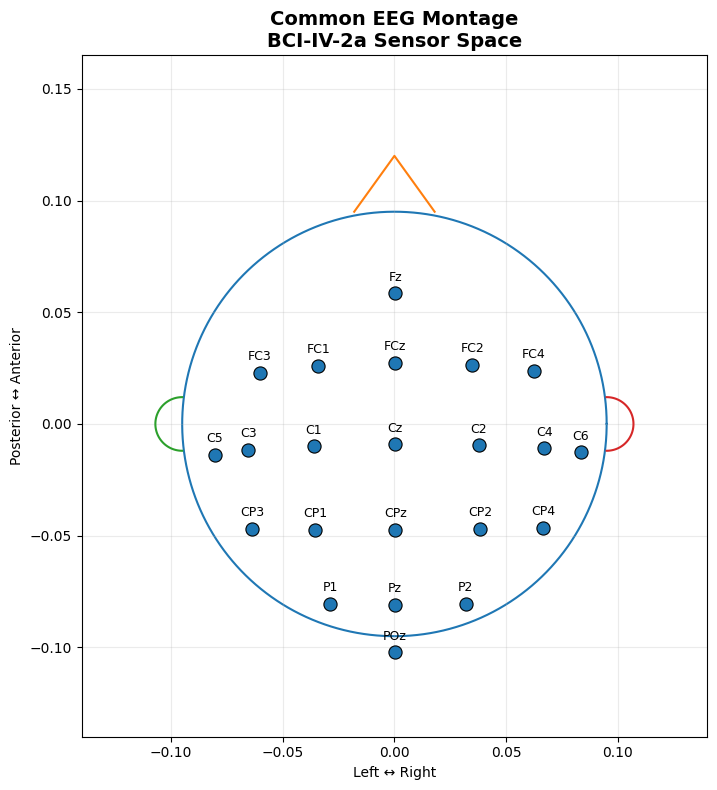


Montage figure saved to:
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/figures/module_4_common_montage.png

Cell 14 visualization validation: PASS


In [32]:
# ============================================================
# CELL 14 — MONTAGE VISUALIZATION (FIXED v2)
# ============================================================

print("=" * 78)
print("COMMON MONTAGE VISUALIZATION")
print("=" * 78)

try:

    # --------------------------------------------------------
    # Use the already-created common_electrodes variable.
    # FROZEN_COMMON_CHANNELS is created later in Cell 15,
    # so it must NOT be referenced here.
    # --------------------------------------------------------

    montage_channels = list(
        common_electrodes
    )

    print(
        "Common electrodes available:",
        len(montage_channels)
    )

    print(
        "Common electrode list:"
    )

    print(
        montage_channels
    )

    # --------------------------------------------------------
    # Load standard 10-20 / 10-10 montage
    # --------------------------------------------------------

    standard_montage = (
        mne.channels.make_standard_montage(
            "standard_1020"
        )
    )

    montage_positions = (
        standard_montage
        .get_positions()
        .get("ch_pos", {})
    )

    # --------------------------------------------------------
    # Obtain coordinates for common electrodes
    # --------------------------------------------------------

    plot_rows = []

    for order, electrode in enumerate(
        montage_channels
    ):

        if electrode in montage_positions:

            xyz = np.asarray(
                montage_positions[electrode],
                dtype=float
            )

            if np.all(
                np.isfinite(xyz)
            ):

                plot_rows.append({
                    "order": order,
                    "electrode": electrode,
                    "x": float(xyz[0]),
                    "y": float(xyz[1]),
                    "z": float(xyz[2]),
                })

    montage_plot_df = pd.DataFrame(
        plot_rows
    )

    missing_plot_channels = [
        ch
        for ch in montage_channels
        if ch not in set(
            montage_plot_df["electrode"]
        )
    ]

    print(
        "\nChannels with standard coordinates:",
        len(montage_plot_df)
    )

    print(
        "Channels without standard coordinates:",
        len(missing_plot_channels)
    )

    if missing_plot_channels:
        print(
            "Missing visualization coordinates:"
        )
        print(
            missing_plot_channels
        )

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 8)
    )

    # --------------------------------------------------------
    # Plot sensors
    # --------------------------------------------------------

    ax.scatter(
        montage_plot_df["x"],
        montage_plot_df["y"],
        s=90,
        edgecolors="black",
        linewidths=0.8,
        zorder=3,
    )

    # --------------------------------------------------------
    # Add electrode labels
    # --------------------------------------------------------

    for _, row in montage_plot_df.iterrows():

        ax.annotate(
            row["electrode"],
            (
                row["x"],
                row["y"],
            ),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    # --------------------------------------------------------
    # Approximate head outline
    # --------------------------------------------------------

    theta = np.linspace(
        0,
        2 * np.pi,
        400
    )

    head_radius = 0.095

    head_x = (
        head_radius
        * np.cos(theta)
    )

    head_y = (
        head_radius
        * np.sin(theta)
    )

    ax.plot(
        head_x,
        head_y,
        linewidth=1.5,
        zorder=1,
    )

    # --------------------------------------------------------
    # Nose
    # --------------------------------------------------------

    nose_x = [
        -0.018,
        0.0,
        0.018,
    ]

    nose_y = [
        head_radius,
        head_radius + 0.025,
        head_radius,
    ]

    ax.plot(
        nose_x,
        nose_y,
        linewidth=1.5,
        zorder=2,
    )

    # --------------------------------------------------------
    # Ears
    # --------------------------------------------------------

    ear_theta = np.linspace(
        -np.pi / 2,
        np.pi / 2,
        100
    )

    ear_radius = 0.012

    # Left ear
    ax.plot(
        -head_radius
        - ear_radius * np.cos(ear_theta),
        ear_radius * np.sin(ear_theta),
        linewidth=1.5,
    )

    # Right ear
    ax.plot(
        head_radius
        + ear_radius * np.cos(ear_theta),
        ear_radius * np.sin(ear_theta),
        linewidth=1.5,
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_title(
        "Common EEG Montage\n"
        "BCI-IV-2a Sensor Space",
        fontsize=14,
        fontweight="bold",
    )

    ax.set_xlabel(
        "Left ↔ Right"
    )

    ax.set_ylabel(
        "Posterior ↔ Anterior"
    )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    padding = 0.14

    ax.set_xlim(
        -padding,
        padding
    )

    ax.set_ylim(
        -padding,
        padding + 0.025
    )

    ax.grid(
        True,
        alpha=0.25
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------

    montage_fig_path = (
        FIGURES_ROOT
        / "module_4_common_montage.png"
    )

    fig.savefig(
        montage_fig_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "\nMontage figure saved to:"
    )

    print(
        montage_fig_path
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if (
        len(missing_plot_channels)
        == 0
    ):

        print(
            "\nCell 14 visualization validation: PASS"
        )

    else:

        print(
            "\nCell 14 visualization validation: "
            "PASS WITH WARNING"
        )

        print(
            "The common montage is valid, but some "
            "electrodes do not have standard plotting "
            "coordinates."
        )

except Exception as exc:

    print(
        "\nMontage visualization failed:"
    )

    print(
        repr(exc)
    )

    raise

## Cell 15 — Channel-order sanity checks

The final deep-learning input convention will be:

**(channels, time)**

with the channel axis ordered identically for both datasets.

This cell verifies that the same canonical list is used everywhere and records
the index order.

In [33]:
# ============================================================
# CELL 15 — CHANNEL ORDER SANITY CHECK
# ============================================================

FROZEN_COMMON_CHANNELS = common_electrodes.copy()

print("=" * 78)
print("FROZEN COMMON CHANNEL ORDER")
print("=" * 78)

for idx, ch in enumerate(FROZEN_COMMON_CHANNELS):
    print(f"{idx:02d}: {ch}")

# Strong invariants
assert len(FROZEN_COMMON_CHANNELS) > 0
assert len(FROZEN_COMMON_CHANNELS) == len(
    set(FROZEN_COMMON_CHANNELS)
)

assert all(
    ch in BCI_IV_2A_22_EEG
    for ch in FROZEN_COMMON_CHANNELS
)

assert common_mapping_df["common_order"].tolist() == list(
    range(len(FROZEN_COMMON_CHANNELS))
)

print("\nChannel order sanity check: PASS")

FROZEN COMMON CHANNEL ORDER
00: Fz
01: FC3
02: FC1
03: FCz
04: FC2
05: FC4
06: C5
07: C3
08: C1
09: Cz
10: C2
11: C4
12: C6
13: CP3
14: CP1
15: CPz
16: CP2
17: CP4
18: P1
19: Pz
20: P2
21: POz

Channel order sanity check: PASS


## Cell 16 — Save the authoritative Module 4 channel map

This is the artifact that Module 5 will consume.

Files saved:
- complete channel mapping
- channel consistency report
- frozen channel list
- BCI channel audit
- PhysioNet channel audit

In [34]:
# ============================================================
# CELL 16 — SAVE MODULE 4 OUTPUTS
# ============================================================

CHANNEL_MAP_PATH = (
    MANIFEST_ROOT / "module_4_common_channel_mapping.csv"
)

CHANNEL_CONSISTENCY_PATH = (
    MANIFEST_ROOT / "module_4_channel_consistency.csv"
)

BCI_CHANNEL_AUDIT_PATH = (
    MANIFEST_ROOT / "module_4_bci_channel_audit.csv"
)

PHYS_CHANNEL_AUDIT_PATH = (
    MANIFEST_ROOT / "module_4_physionet_channel_audit.csv"
)

FROZEN_CHANNELS_PATH = (
    MANIFEST_ROOT / "module_4_frozen_common_channels.json"
)

common_mapping_df.to_csv(
    CHANNEL_MAP_PATH,
    index=False,
)

channel_consistency_df.to_csv(
    CHANNEL_CONSISTENCY_PATH,
    index=False,
)

bci_channel_audit_df.to_csv(
    BCI_CHANNEL_AUDIT_PATH,
    index=False,
)

phys_rep_df.to_csv(
    PHYS_CHANNEL_AUDIT_PATH,
    index=False,
)

frozen_spec = {
    "module": 4,
    "common_channel_space": "BCI-IV-2a EEG sensor space",
    "n_common_channels": len(FROZEN_COMMON_CHANNELS),
    "channels": FROZEN_COMMON_CHANNELS,
    "auxiliary_channels_excluded": True,
    "bci_eog_excluded": True,
    "physionet_extra_channels_excluded": True,
    "interpolation_used": False,
    "mapping_method": (
        "BCI canonical sensor identity + PhysioNet international 10-10 identity"
    ),
}

with open(FROZEN_CHANNELS_PATH, "w", encoding="utf-8") as f:
    json.dump(frozen_spec, f, indent=2)

print("=" * 78)
print("MODULE 4 OUTPUTS SAVED")
print("=" * 78)

for path in [
    CHANNEL_MAP_PATH,
    CHANNEL_CONSISTENCY_PATH,
    BCI_CHANNEL_AUDIT_PATH,
    PHYS_CHANNEL_AUDIT_PATH,
    FROZEN_CHANNELS_PATH,
]:
    print(path)

MODULE 4 OUTPUTS SAVED
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_4_common_channel_mapping.csv
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_4_channel_consistency.csv
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_4_bci_channel_audit.csv
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_4_physionet_channel_audit.csv
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_4_frozen_common_channels.json


## Cell 17 — Module 4 validation report

### PASS

The common electrode space is supported by actual channel metadata and is
available in every retained recording.

### PASS WITH WARNING

The common space is valid, but some metadata are incomplete or require a
documented fallback.

### FAIL

Do not proceed if:
- BCI does not expose 22 EEG + 3 EOG;
- retained recordings disagree in channel structure;
- any retained recording lacks a common electrode;
- an auxiliary channel has entered the common space;
- the mapping depends on an unverified guess.

In [35]:
# ============================================================
# CELL 17 — MODULE 4 VALIDATION REPORT
# ============================================================

validation = {}

validation["bci_structure_valid"] = bool(bci_structure_valid)
validation["bci_order_consistent"] = bool(order_consistent)
validation["common_montage_nonempty"] = len(FROZEN_COMMON_CHANNELS) > 0
validation["all_bci_common_channels"] = len(missing_from_physionet) == 0
validation["all_retained_recordings_complete"] = len(problems) == 0
validation["mapping_has_unique_rows"] = (
    len(common_mapping_df)
    == common_mapping_df[
        "canonical_electrode"
    ].nunique()
)
validation["auxiliary_channels_excluded"] = True
validation["interpolation_used"] = False
validation["map_saved"] = CHANNEL_MAP_PATH.exists()
validation["frozen_spec_saved"] = FROZEN_CHANNELS_PATH.exists()

critical_checks = [
    validation["bci_structure_valid"],
    validation["bci_order_consistent"],
    validation["common_montage_nonempty"],
    validation["all_bci_common_channels"],
    validation["all_retained_recordings_complete"],
    validation["mapping_has_unique_rows"],
    validation["auxiliary_channels_excluded"],
    validation["map_saved"],
    validation["frozen_spec_saved"],
]

module_status = "PASS" if all(critical_checks) else "FAIL"

print("=" * 78)
print("MODULE VALIDATION REPORT — MODULE 4")
print("=" * 78)

for key, value in validation.items():
    print(f"{key:42s}: {value}")

print("\nCommon channel count:", len(FROZEN_COMMON_CHANNELS))
print("Common channels:", FROZEN_COMMON_CHANNELS)
print("\nInterpolation used:", False)

print("\nStatus:", module_status)

if module_status == "PASS":
    print("\nFINAL MODULE STATUS: PASS")
    print(
        "The common EEG sensor space is frozen and can be used by Module 5."
    )
else:
    print("\nFINAL MODULE STATUS: FAIL")
    print(
        "Do NOT proceed to Module 5 until the mapping is scientifically resolved."
    )

MODULE VALIDATION REPORT — MODULE 4
bci_structure_valid                       : True
bci_order_consistent                      : True
common_montage_nonempty                   : True
all_bci_common_channels                   : True
all_retained_recordings_complete          : True
mapping_has_unique_rows                   : True
auxiliary_channels_excluded               : True
interpolation_used                        : False
map_saved                                 : True
frozen_spec_saved                         : True

Common channel count: 22
Common channels: ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']

Interpolation used: False

Status: PASS

FINAL MODULE STATUS: PASS
The common EEG sensor space is frozen and can be used by Module 5.


# MODULE 4 STOP CONDITION

Before continuing to Module 5, review:

1. BCI channel type counts.
2. The complete BCI raw-to-canonical mapping.
3. PhysioNet raw-to-standard mapping.
4. The common electrode table.
5. Missing-electrode report.
6. All-recording consistency results.
7. The montage visualization.
8. Final Module 4 validation status.

The next module will use this frozen sensor space for:
- re-referencing,
- filtering,
- sampling-rate harmonization,
- artifact handling,
- normalization design,
- PSD/spectrogram inspection.

No model training starts until preprocessing is validated.